In [1]:
import numpy as np
import pandas as pd
import os

image_index = {
    'face': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
    'body': [26, 27, 28, 29, 30, 31, 43, 44, 45, 46, 47, 48, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61],
    'object': [25, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 49, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72]
}
face_idx = np.array([i - 1 for i in image_index['face']])
body_idx = np.array([i - 1 for i in image_index['body']])
object_idx = np.array([i - 1 for i in image_index['object']])
nonface_idx = np.concatenate([body_idx, object_idx])
nonbody_idx = np.concatenate([face_idx, object_idx])
nonobject_idx = np.concatenate([face_idx, body_idx])

In [2]:
def compute_si(rsp_cat, rsp_noncat, eps=1e-10):
    m_cat = np.mean(rsp_cat)
    m_non = np.mean(rsp_noncat)
    v_cat = np.var(rsp_cat)
    v_non = np.var(rsp_noncat)
    denom = np.sqrt(0.5 * (v_cat + v_non) + eps)
    return (m_cat - m_non) / denom

def process_mua_group(unit_info, responses_72):
    mean_firing_rate = np.log10(responses_72.mean(axis=1) + 1e-10)
    F_SI = np.array([compute_si(r[face_idx], r[nonface_idx]) for r in responses_72])
    B_SI = np.array([compute_si(r[body_idx], r[nonbody_idx]) for r in responses_72])
    O_SI = np.array([compute_si(r[object_idx], r[nonobject_idx]) for r in responses_72])
    unit_info = unit_info.copy()
    unit_info['mean_firing_rate'] = mean_firing_rate
    unit_info['F_SI'] = F_SI
    unit_info['B_SI'] = B_SI
    unit_info['O_SI'] = O_SI
    unit_info['Face_selectivity'] = (F_SI > 0.3).astype(int)
    unit_info['Body_selectivity'] = (B_SI > 0.3).astype(int)
    unit_info['Object_selectivity'] = (O_SI > 0.3).astype(int)
    return unit_info

OUT_DIR = '/media/ubuntu/sda/TrippleN/customize/mua'
THRESHOLDS = [103, 206, 409, 612]

In [3]:
for th in THRESHOLDS:
    unit_info = pd.read_pickle(os.path.join(OUT_DIR, f'mua_unit_info_{th}.pkl'))
    responses_72 = np.load(os.path.join(OUT_DIR, f'mua_responses_72_{th}.npy'))
    unit_info = process_mua_group(unit_info, responses_72)
    unit_info.to_pickle(os.path.join(OUT_DIR, f'mua_unit_info_{th}.pkl'))
    print(f'threshold {th}: n={len(unit_info)}, mean_firing_rate range [{unit_info["mean_firing_rate"].min():.3f}, {unit_info["mean_firing_rate"].max():.3f}]')

unit_info = pd.read_pickle(os.path.join(OUT_DIR, 'mua_unit_info_session.pkl'))
responses_72 = np.load(os.path.join(OUT_DIR, 'mua_responses_72_session.npy'))
unit_info = process_mua_group(unit_info, responses_72)
unit_info.to_pickle(os.path.join(OUT_DIR, 'mua_unit_info_session.pkl'))
print(f'session: n={len(unit_info)}, mean_firing_rate range [{unit_info["mean_firing_rate"].min():.3f}, {unit_info["mean_firing_rate"].max():.3f}]')

threshold 103: n=7233, mean_firing_rate range [-1.481, 1.627]
threshold 206: n=11060, mean_firing_rate range [-0.710, 1.360]
threshold 409: n=7471, mean_firing_rate range [0.267, 1.221]
threshold 612: n=5898, mean_firing_rate range [0.251, 1.230]
session: n=51, mean_firing_rate range [0.510, 1.150]


SUA vs 103: p=0.0002 ***
SUA vs 206: p=0.0000 ***
SUA vs 409: p=0.0000 ***
SUA vs 612: p=0.0000 ***
SUA vs session: p=0.0000 ***


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/scipy/stats/_multicomp.py:421: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  s2 = np.sum([_var(sample, mean=mean)*sample.size


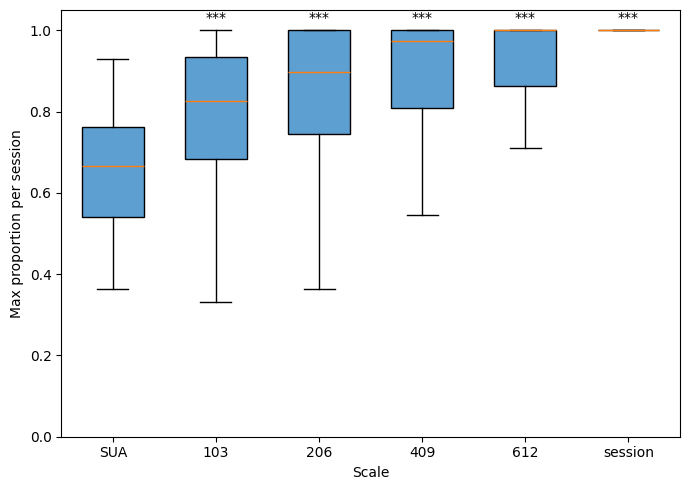

In [4]:
import matplotlib.pyplot as plt
import scikit_posthocs as sp

SUA_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'
FIG_DIR = '/media/ubuntu/sda/TrippleN/customize/figures'

def ensure_selectivity(ui):
    if 'Face_selectivity' not in ui.columns:
        ui = ui.copy()
        ui['Face_selectivity'] = (ui['F_SI'] > 0.3).astype(int)
        ui['Body_selectivity'] = (ui['B_SI'] > 0.3).astype(int)
        ui['Object_selectivity'] = (ui['O_SI'] > 0.3).astype(int)
    return ui

def pct_per_session(ui):
    B = ui['Body_selectivity'].values
    F = ui['Face_selectivity'].values
    O = ui['Object_selectivity'].values
    n_sel = B + F + O
    non = (n_sel == 0).sum()
    face = ((F == 1) & (B == 0) & (O == 0)).sum()
    body = ((B == 1) & (F == 0) & (O == 0)).sum()
    obj = ((O == 1) & (B == 0) & (F == 0)).sum()
    multi = (n_sel >= 2).sum()
    n = len(ui)
    pcts = np.array([non, face, body, obj, multi], dtype=float) / n if n > 0 else np.zeros(5)
    return np.max(pcts)

scales = ['SUA', '103', '206', '409', '612', 'session']
sua = ensure_selectivity(pd.read_pickle(SUA_PATH))
all_ui = [sua] + [pd.read_pickle(os.path.join(OUT_DIR, f'mua_unit_info_{th}.pkl')) for th in THRESHOLDS] + [pd.read_pickle(os.path.join(OUT_DIR, 'mua_unit_info_session.pkl'))]
common_sids = sorted(sua['session_id'].unique())
rows = []
for sid in common_sids:
    for scale, ui in zip(scales, all_ui):
        grp = ui[ui['session_id'] == sid]
        if len(grp) > 0:
            rows.append({'session_id': sid, 'scale': scale, 'value': pct_per_session(grp)})
df = pd.DataFrame(rows)

df['scale'] = pd.Categorical(df['scale'], categories=scales, ordered=True)
df = df.sort_values('scale')

fig, ax = plt.subplots(figsize=(7, 5))
data = [df[df['scale'] == s]['value'].values for s in scales]
bp = ax.boxplot(data, positions=range(len(scales)), widths=0.6, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor('#5E9FD1')
ax.set_ylim(0, 1.05)
ax.set_xticks(range(len(scales)))
ax.set_xticklabels(scales)
ax.set_ylabel('Max proportion per session')
ax.set_xlabel('Scale')

dunnett = sp.posthoc_dunnett(df, val_col='value', group_col='scale', control='SUA')
y_max = df['value'].max()
for i, s in enumerate(scales[1:]):
    p = dunnett.loc['SUA', s]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(i + 1, y_max + 0.02, sig, ha='center', fontsize=10)
    print(f'SUA vs {s}: p={p:.4f} {sig}')
os.makedirs(FIG_DIR, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'selectivity_richness_by_scale.pdf'), bbox_inches='tight')
plt.show()

In [6]:
from sklearn.decomposition import PCA

PSTH_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
UNIT_INFO_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'
N_SAMPLE, N_ITER, N_PC = 5000, 100, 20
SCALES_PLOT = ['SUA', '103', '206', '409', '612']

def load_sua_responses_72():
    psth = np.load(PSTH_PATH, mmap_mode='r')
    ui = pd.read_pickle(UNIT_INFO_PATH)
    n_neurons, n_stimuli, n_time = psth.shape
    t1 = np.clip(ui['best_r_time1'].values.astype(int), 0, n_time - 1)
    t2 = np.clip(ui['best_r_time2'].values.astype(int), 1, n_time)
    t2 = np.maximum(t2, t1 + 1)
    out = np.zeros((len(ui), 72), dtype=np.float32)
    for i in range(len(ui)):
        s, e = t1[i], t2[i]
        out[i] = np.mean(psth[i, 1000:1072, s:e], axis=1)
    return out

def centroid_and_distances(X_72_20):
    c_face = X_72_20[face_idx].mean(axis=0)
    c_body = X_72_20[body_idx].mean(axis=0)
    c_obj = X_72_20[object_idx].mean(axis=0)
    d_fb = np.linalg.norm(c_face - c_body)
    d_fo = np.linalg.norm(c_face - c_obj)
    d_bo = np.linalg.norm(c_body - c_obj)
    return np.array([d_fb, d_fo, d_bo])

def between_category_ss(X_72_20):
    c_face = X_72_20[face_idx].mean(axis=0)
    c_body = X_72_20[body_idx].mean(axis=0)
    c_obj = X_72_20[object_idx].mean(axis=0)
    grand = X_72_20.mean(axis=0)
    ss_between = 24 * (np.sum((c_face - grand)**2) + np.sum((c_body - grand)**2) + np.sum((c_obj - grand)**2))
    return ss_between

print('Loading SUA responses_72...')
sua_r72 = load_sua_responses_72()
scale_responses = {'SUA': sua_r72}
for th in THRESHOLDS:
    scale_responses[str(th)] = np.load(os.path.join(OUT_DIR, f'mua_responses_72_{th}.npy'))

result = np.zeros((N_ITER, 3, 5))
result_variance_ratio = np.zeros((N_ITER, 5))
np.random.seed(42)
for scale_idx, scale_name in enumerate(SCALES_PLOT):
    R = scale_responses[scale_name]
    n_units = R.shape[0]
    for it in range(N_ITER):
        idx = np.random.choice(n_units, size=min(N_SAMPLE, n_units), replace=False)
        X = R[idx]
        X_t = X.T
        pca = PCA(n_components=min(N_PC, X_t.shape[0] - 1, X_t.shape[1] - 1))
        X_72_20 = pca.fit_transform(X_t)
        result[it, :, scale_idx] = centroid_and_distances(X_72_20)
        result_variance_ratio[it, scale_idx] = between_category_ss(X_72_20)
    print(f'{scale_name}: shape {result[:, :, scale_idx].shape}, mean distances {result[:, :, scale_idx].mean(axis=0)}, mean between_ss {result_variance_ratio[:, scale_idx].mean():.2f}')

dist_labels = ['face-body', 'face-object', 'body-object']
print('Mean (100 iters) per scale:')
for j, lab in enumerate(dist_labels):
    print(lab, result[:, j, :].mean(axis=0))
print('Between-category SS mean per scale:', result_variance_ratio.mean(axis=0))

Loading SUA responses_72...
SUA: shape (100, 3), mean distances [613.97176819 546.47157043 306.59054077], mean between_ss 6161785.12
103: shape (100, 3), mean distances [468.55184387 416.02609283 219.03794739], mean between_ss 3525043.74
206: shape (100, 3), mean distances [435.68841766 379.41605194 209.12921616], mean between_ss 3020507.06
409: shape (100, 3), mean distances [423.34736115 366.4325058  201.02200653], mean between_ss 2831413.69
612: shape (100, 3), mean distances [411.14188843 354.42718933 192.57802048], mean between_ss 2654035.15
Mean (100 iters) per scale:
face-body [613.97176819 468.55184387 435.68841766 423.34736115 411.14188843]
face-object [546.47157043 416.02609283 379.41605194 366.4325058  354.42718933]
body-object [306.59054077 219.03794739 209.12921616 201.02200653 192.57802048]
Between-category SS mean per scale: [6161785.12125  3525043.74375  3020507.056875 2831413.685625
 2654035.153125]


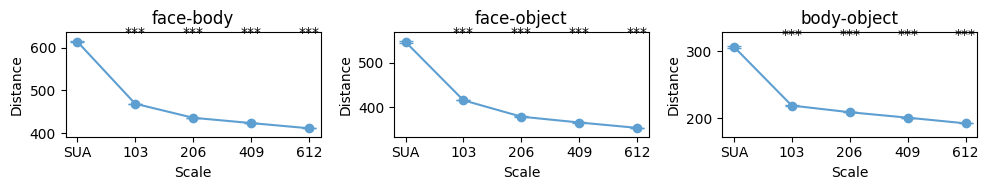

In [7]:
import matplotlib.pyplot as plt
import scikit_posthocs as sp
import numpy as np
FIG_DIR = '/media/ubuntu/sda/TrippleN/customize/figures'
dist_labels = ['face-body', 'face-object', 'body-object']
x_cond = np.arange(len(SCALES_PLOT))
means = result.mean(axis=0)
sems = result.std(axis=0) / np.sqrt(N_ITER)

fig, axes = plt.subplots(1, 3, figsize=(10, 2))
for j, (ax, lab) in enumerate(zip(axes, dist_labels)):
    ax.errorbar(x_cond, means[j], yerr=sems[j], fmt='o-', capsize=5, color='#5E9FD1', capthick=1)
    ax.set_xticks(x_cond)
    ax.set_xticklabels(SCALES_PLOT)
    ax.set_ylabel('Distance')
    ax.set_title(lab)
    ax.set_xlabel('Scale')
    rows = [{'value': result[i, j, k], 'condition': SCALES_PLOT[k]} for i in range(N_ITER) for k in range(5)]
    df_d = pd.DataFrame(rows)
    dunnett = sp.posthoc_dunnett(df_d, val_col='value', group_col='condition', control='SUA')
    y_max = (means[j] + sems[j]).max()
    y_min = (means[j] + sems[j]).min()
    for ki, cond in enumerate(SCALES_PLOT[1:]):
        p = dunnett.loc['SUA', cond]
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        ax.text(ki + 1, y_max + 10, sig, ha='center', fontsize=10)
    ax.set_ylim(y_min - 20, y_max + 20)
    
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'category_distance_by_scale.pdf'), bbox_inches='tight')
plt.show()

SUA vs 103 between_ss: p=0.0000 ***
SUA vs 206 between_ss: p=0.0000 ***
SUA vs 409 between_ss: p=0.0000 ***
SUA vs 612 between_ss: p=0.0000 ***


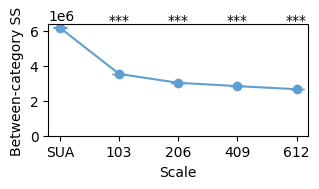

In [8]:
vr_means = result_variance_ratio.mean(axis=0)
vr_sems = result_variance_ratio.std(axis=0) / np.sqrt(N_ITER)
x_cond = np.arange(len(SCALES_PLOT))

fig, ax = plt.subplots(figsize=(3.3, 2))
ax.errorbar(x_cond, vr_means, yerr=vr_sems, fmt='o-', capsize=5, color='#5E9FD1', capthick=1)
ax.set_xticks(x_cond)
ax.set_xticklabels(SCALES_PLOT)
ax.set_ylabel('Between-category SS')
ax.set_xlabel('Scale')
ax.set_ylim(bottom=0)

rows_vr = [{'value': result_variance_ratio[i, k], 'condition': SCALES_PLOT[k]} for i in range(N_ITER) for k in range(5)]
df_vr = pd.DataFrame(rows_vr)
dunnett_vr = sp.posthoc_dunnett(df_vr, val_col='value', group_col='condition', control='SUA')
y_max_vr = (vr_means + vr_sems).max()
y_range = y_max_vr - (vr_means - vr_sems).min()
for ki, cond in enumerate(SCALES_PLOT[1:]):
    p = dunnett_vr.loc['SUA', cond]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(ki + 1, y_max_vr + 0.05 * y_range, sig, ha='center', fontsize=10)
    print(f'SUA vs {cond} between_ss: p={p:.4f} {sig}')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'variance_ratio_by_scale.pdf'), bbox_inches='tight')
plt.show()

SUA vs 103: p=0.0453 *
SUA vs 206: p=0.0050 **
SUA vs 409: p=0.0014 **
SUA vs 612: p=0.0015 **


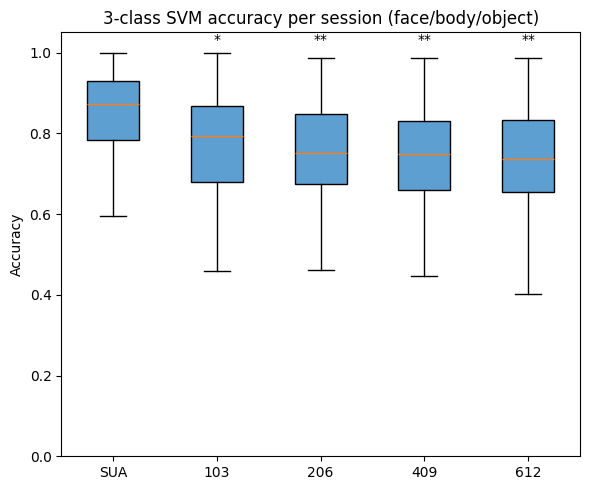

In [9]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import scikit_posthocs as sp

PSTH_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
SUA_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'
FIG_DIR = '/media/ubuntu/sda/TrippleN/customize/figures'

y_72 = np.zeros(72, dtype=int)
y_72[face_idx] = 0
y_72[body_idx] = 1
y_72[object_idx] = 2

psth_data = np.load(PSTH_PATH, mmap_mode='r')
sua_ui = pd.read_pickle(SUA_PATH)
n_neurons = psth_data.shape[0]
n_stimuli = psth_data.shape[1]
n_time = psth_data.shape[2]
best_r_time1 = sua_ui['best_r_time1'].values
best_r_time2 = sua_ui['best_r_time2'].values
neuron_responses = np.zeros((n_neurons, n_stimuli), dtype=np.float32)
for neuron_idx in range(n_neurons):
    start_time = int(best_r_time1[neuron_idx])
    end_time = int(best_r_time2[neuron_idx])
    if start_time < 0:
        start_time = 0
    if end_time > n_time:
        end_time = n_time
    if end_time <= start_time:
        mid_time = n_time // 2
        start_time = max(0, mid_time - 5)
        end_time = min(n_time, mid_time + 5)
    psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
    neuron_responses[neuron_idx] = np.mean(psth_neuron, axis=1)
sua_r72 = neuron_responses[:, 1000:]

MIN_UNITS = 5
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scales_svm = ['SUA', '103', '206', '409', '612']
accuracies = {s: [] for s in scales_svm}
for sid in sorted(sua_ui['session_id'].unique()):
    mask = sua_ui['session_id'].values == sid
    n_u = mask.sum()
    if n_u < MIN_UNITS:
        continue
    X = sua_r72[mask].T
    acc = cross_val_score(SVC(kernel='linear', C=1.0), X, y_72, cv=CV, n_jobs=-1).mean()
    accuracies['SUA'].append(acc)

for th in THRESHOLDS:
    ui = pd.read_pickle(os.path.join(OUT_DIR, f'mua_unit_info_{th}.pkl'))
    r72 = np.load(os.path.join(OUT_DIR, f'mua_responses_72_{th}.npy'))
    for sid in sorted(ui['session_id'].unique()):
        mask = ui['session_id'].values == sid
        n_u = mask.sum()
        if n_u < MIN_UNITS:
            continue
        X = r72[mask].T
        acc = cross_val_score(SVC(kernel='linear', C=1.0), X, y_72, cv=CV, n_jobs=-1).mean()
        accuracies[str(th)].append(acc)

df_svm = pd.DataFrame([{'scale': s, 'value': v} for s in scales_svm for v in accuracies[s]])
dunnett = sp.posthoc_dunnett(df_svm, val_col='value', group_col='scale', control='SUA')
y_max = max(np.max(accuracies[s]) for s in scales_svm)

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
data = [accuracies[s] for s in scales_svm]
bp = ax.boxplot(data, tick_labels=scales_svm, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#5E9FD1')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('3-class SVM accuracy per session (face/body/object)')
for i, s in enumerate(scales_svm[1:]):
    p = dunnett.loc['SUA', s]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.text(i + 2, y_max + 0.02, sig, ha='center', fontsize=10)
    print(f'SUA vs {s}: p={p:.4f} {sig}')
plt.tight_layout()
os.makedirs(FIG_DIR, exist_ok=True)
plt.savefig(os.path.join(FIG_DIR, 'svm_3class_by_scale.pdf'), bbox_inches='tight')
plt.show()

In [4]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster import hierarchy

CLUSINFO_PATH = '/media/ubuntu/sda/TrippleN/ClusInfo.mat'
SCALES_1000 = [103, 206, 409, 612, 'session']

cluster_info = loadmat(CLUSINFO_PATH)['Cluster_idx']
cluster_flat = np.asarray(cluster_info).flatten()
cluster_ids = np.unique(cluster_flat)
n_clusters = len(cluster_ids)
cmap_cluster = plt.cm.tab20
col_color = np.array([cmap_cluster(i % 20) for i in range(n_clusters)])
col_color_hex = ['#%02x%02x%02x' % (int(r*255), int(g*255), int(b*255)) for r, g, b, _ in col_color]

for scale in SCALES_1000:
    fname = f'mua_responses_1000_session.npy' if scale == 'session' else f'mua_responses_1000_{scale}.npy'
    responses_1000 = np.load(os.path.join(OUT_DIR, fname))
    n_units = responses_1000.shape[0]
    rmin = responses_1000.min(axis=1, keepdims=True)
    rmax = responses_1000.max(axis=1, keepdims=True)
    R = 2 * (responses_1000.astype(np.float64) - rmin) / (rmax - rmin + 1e-10) - 1
    SI_clusters = np.zeros((n_units, n_clusters))
    for j in range(n_clusters):
        mask_c = (cluster_flat == cluster_ids[j])
        mask_n = ~mask_c
        m_cat = R[:, mask_c].mean(axis=1)
        m_non = R[:, mask_n].mean(axis=1)
        v_cat = R[:, mask_c].var(axis=1)
        v_non = R[:, mask_n].var(axis=1)
        SI_clusters[:, j] = (m_cat - m_non) / np.sqrt(0.5 * (v_cat + v_non) + 1e-10)
    mua_1000_info = pd.DataFrame(index=range(n_units))
    for j in range(n_clusters):
        mua_1000_info[f'C{j}_SI'] = SI_clusters[:, j]
        mua_1000_info[f'C{j}_selectivity'] = (SI_clusters[:, j] > 0.3).astype(int)
    n_cluster_sel = sum(mua_1000_info[f'C{j}_selectivity'] for j in range(n_clusters))
    mua_1000_info['cluster_tuning_type'] = 'multi_tuning'
    mua_1000_info.loc[n_cluster_sel == 0, 'cluster_tuning_type'] = 'no_tuning'
    mua_1000_info.loc[n_cluster_sel == 1, 'cluster_tuning_type'] = 'single_tuning'
    selective_cluster = np.full(n_units, -1, dtype=int)
    for j in range(n_clusters):
        selective_cluster[(mua_1000_info[f'C{j}_selectivity'] == 1).values & (n_cluster_sel == 1)] = j
    mua_1000_info['selective_cluster_idx'] = selective_cluster
    R_raw = responses_1000.astype(np.float64)
    R_by_cluster = np.zeros((n_units, n_clusters))
    for j, cid in enumerate(cluster_ids):
        mask = cluster_flat == cid
        R_by_cluster[:, j] = R_raw[:, mask].mean(axis=1)
    r_min = R_by_cluster.min(axis=1, keepdims=True)
    r_max = R_by_cluster.max(axis=1, keepdims=True)
    range_r = r_max - r_min
    range_r[range_r == 0] = 1
    R_norm = 2 * (R_by_cluster - r_min) / range_r - 1
    col_linkage = hierarchy.linkage(R_norm.T, method='average')
    col_order = hierarchy.leaves_list(col_linkage)
    col_order_inv = np.zeros(n_clusters, dtype=int)
    col_order_inv[col_order] = np.arange(n_clusters)
    single_mask = (mua_1000_info['cluster_tuning_type'] == 'single_tuning').values
    multi_mask = (mua_1000_info['cluster_tuning_type'] == 'multi_tuning').values
    no_mask = (mua_1000_info['cluster_tuning_type'] == 'no_tuning').values
    single_idx = np.where(single_mask)[0]
    single_sort = single_idx[np.argsort(col_order_inv[selective_cluster[single_idx]])]
    sort_idx = np.concatenate([single_sort, np.where(multi_mask)[0], np.where(no_mask)[0]])
    R_norm = R_norm[sort_idx]
    tuning_type_ordered = mua_1000_info['cluster_tuning_type'].values[sort_idx]
    sel_cluster_ordered = selective_cluster[sort_idx]
    row_color_by_tuning = np.array(['#e0e0e0'] * len(sort_idx))
    row_color_by_tuning[tuning_type_ordered == 'multi_tuning'] = '#EC6F7E'
    for j in range(n_clusters):
        row_color_by_tuning[(tuning_type_ordered == 'single_tuning') & (sel_cluster_ordered == j)] = col_color_hex[j]
    R_plot = R_norm
    row_colors = [np.asarray(row_color_by_tuning)]
    col_colors = [np.asarray(col_color_hex)]
    g = sns.clustermap(R_plot, row_cluster=False, col_cluster=True, method='average',
                       cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                       figsize=(12, 8), dendrogram_ratio=(0.15, 0.1),
                       row_colors=row_colors, col_colors=col_colors)
    g.ax_heatmap.set_xlabel('Cluster')
    g.ax_heatmap.set_ylabel('MUA unit')
    plt.suptitle(f'MUA 1000 (scale={scale}): single | multi | no, n={n_units}', y=1.02)
    pdf_name = f'mua_1000_heatmap_session.pdf' if scale == 'session' else f'mua_1000_heatmap_th{scale}.pdf'
    heatmap_pdf = os.path.join(OUT_DIR, pdf_name)
    g.fig.savefig(heatmap_pdf, bbox_inches='tight')
    plt.close(g.fig)
    n_single = (mua_1000_info['cluster_tuning_type'] == 'single_tuning').sum()
    n_multi = (mua_1000_info['cluster_tuning_type'] == 'multi_tuning').sum()
    n_no = (mua_1000_info['cluster_tuning_type'] == 'no_tuning').sum()
    print(f'  scale={scale}: n={n_units}, 单一={n_single}, 多种={n_multi}, 无={n_no} -> Saved {pdf_name}')

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


  scale=103: n=7233, 单一=1714, 多种=5135, 无=384 -> Saved mua_1000_heatmap_th103.pdf


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


  scale=206: n=11060, 单一=2169, 多种=8547, 无=344 -> Saved mua_1000_heatmap_th206.pdf


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


  scale=409: n=7471, 单一=1302, 多种=6019, 无=150 -> Saved mua_1000_heatmap_th409.pdf


/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


  scale=612: n=5898, 单一=1029, 多种=4786, 无=83 -> Saved mua_1000_heatmap_th612.pdf
  scale=session: n=51, 单一=7, 多种=43, 无=1 -> Saved mua_1000_heatmap_session.pdf


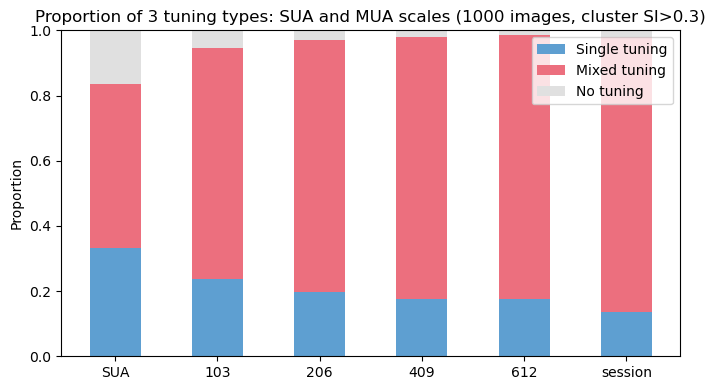

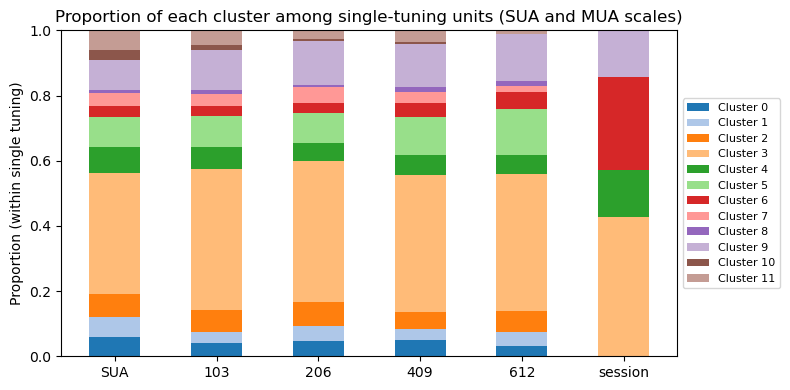

     scale  single  multi    no  total
0      SUA    5209   7875  2568  15652
1      103    1714   5135   384   7233
2      206    2169   8547   344  11060
3      409    1302   6019   150   7471
4      612    1029   4786    83   5898
5  session       7     43     1     51


In [5]:
from scipy.io import loadmat

OUT_DIR = '/media/ubuntu/sda/TrippleN/customize/mua'
CLUSINFO_PATH = '/media/ubuntu/sda/TrippleN/ClusInfo.mat'
SCALES_1000 = [103, 206, 409, 612, 'session']

cluster_info = loadmat(CLUSINFO_PATH)['Cluster_idx']
cluster_flat = np.asarray(cluster_info).flatten()
cluster_ids = np.unique(cluster_flat)
n_clusters = len(cluster_ids)

def get_three_way_counts(responses_1000, cluster_flat, cluster_ids, n_clusters):
    n_units = responses_1000.shape[0]
    rmin = responses_1000.min(axis=1, keepdims=True)
    rmax = responses_1000.max(axis=1, keepdims=True)
    R = 2 * (responses_1000.astype(np.float64) - rmin) / (rmax - rmin + 1e-10) - 1
    SI_clusters = np.zeros((n_units, n_clusters))
    for j in range(n_clusters):
        mask_c = (cluster_flat == cluster_ids[j])
        mask_n = ~mask_c
        m_cat = R[:, mask_c].mean(axis=1)
        m_non = R[:, mask_n].mean(axis=1)
        v_cat = R[:, mask_c].var(axis=1)
        v_non = R[:, mask_n].var(axis=1)
        SI_clusters[:, j] = (m_cat - m_non) / np.sqrt(0.5 * (v_cat + v_non) + 1e-10)
    sel = (SI_clusters > 0.3).astype(int)
    n_cluster_sel = sel.sum(axis=1)
    n_single = (n_cluster_sel == 1).sum()
    n_multi = (n_cluster_sel >= 2).sum()
    n_no = (n_cluster_sel == 0).sum()
    return n_single, n_multi, n_no

def get_single_tuning_cluster_counts(responses_1000, cluster_flat, cluster_ids, n_clusters):
    n_units = responses_1000.shape[0]
    rmin = responses_1000.min(axis=1, keepdims=True)
    rmax = responses_1000.max(axis=1, keepdims=True)
    R = 2 * (responses_1000.astype(np.float64) - rmin) / (rmax - rmin + 1e-10) - 1
    SI_clusters = np.zeros((n_units, n_clusters))
    for j in range(n_clusters):
        mask_c = (cluster_flat == cluster_ids[j])
        mask_n = ~mask_c
        m_cat = R[:, mask_c].mean(axis=1)
        m_non = R[:, mask_n].mean(axis=1)
        v_cat = R[:, mask_c].var(axis=1)
        v_non = R[:, mask_n].var(axis=1)
        SI_clusters[:, j] = (m_cat - m_non) / np.sqrt(0.5 * (v_cat + v_non) + 1e-10)
    sel = (SI_clusters > 0.3).astype(int)
    n_cluster_sel = sel.sum(axis=1)
    single_mask = (n_cluster_sel == 1)
    count_per_cluster = np.zeros(n_clusters, dtype=int)
    for i in np.where(single_mask)[0]:
        j = np.where(sel[i] == 1)[0][0]
        count_per_cluster[j] += 1
    return count_per_cluster

PSTH_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy' 
UNIT_INFO_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'

psth_data = np.load(PSTH_PATH, mmap_mode='r')
sua_unit_info = pd.read_pickle(UNIT_INFO_PATH)
n_neurons = psth_data.shape[0]
n_stimuli = psth_data.shape[1]
n_time = psth_data.shape[2]
best_r_time1 = sua_unit_info['best_r_time1'].values
best_r_time2 = sua_unit_info['best_r_time2'].values
neuron_responses = np.zeros((n_neurons, min(1000, n_stimuli)), dtype=np.float32)
for i in range(n_neurons):
    s, e = int(best_r_time1[i]), int(best_r_time2[i])
    s, e = max(0, s), min(n_time, e)
    if e <= s:
        s, e = max(0, n_time//2 - 5), min(n_time, n_time//2 + 5)
    neuron_responses[i] = np.mean(psth_data[i, :neuron_responses.shape[1], s:e], axis=1)
sua_responses_1000 = neuron_responses[:, :1000]
del neuron_responses, psth_data

rows = []
rows_single = []
n_s, n_m, n_n = get_three_way_counts(sua_responses_1000, cluster_flat, cluster_ids, n_clusters)
rows.append({'scale': 'SUA', 'single': n_s, 'multi': n_m, 'no': n_n})
cnt = get_single_tuning_cluster_counts(sua_responses_1000, cluster_flat, cluster_ids, n_clusters)
rows_single.append({'scale': 'SUA', **{f'C{j}': cnt[j] for j in range(n_clusters)}})
for scale in SCALES_1000:
    fname = f'mua_responses_1000_session.npy' if scale == 'session' else f'mua_responses_1000_{scale}.npy'
    r1000 = np.load(os.path.join(OUT_DIR, fname))
    n_s, n_m, n_n = get_three_way_counts(r1000, cluster_flat, cluster_ids, n_clusters)
    rows.append({'scale': str(scale), 'single': n_s, 'multi': n_m, 'no': n_n})
    cnt = get_single_tuning_cluster_counts(r1000, cluster_flat, cluster_ids, n_clusters)
    rows_single.append({'scale': str(scale), **{f'C{j}': cnt[j] for j in range(n_clusters)}})

df_stack = pd.DataFrame(rows)
df_stack['total'] = df_stack['single'] + df_stack['multi'] + df_stack['no']
df_stack['p_single'] = df_stack['single'] / df_stack['total']
df_stack['p_multi'] = df_stack['multi'] / df_stack['total']
df_stack['p_no'] = df_stack['no'] / df_stack['total']

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(df_stack))
w = 0.5
ax.bar(x, df_stack['p_single'], width=w, label='Single tuning', color='#5E9FD1')
ax.bar(x, df_stack['p_multi'], width=w, bottom=df_stack['p_single'], label='Mixed tuning', color='#EC6F7E')
ax.bar(x, df_stack['p_no'], width=w, bottom=df_stack['p_single']+df_stack['p_multi'], label='No tuning', color='#e0e0e0')
ax.set_xticks(x)
ax.set_xticklabels(df_stack['scale'])
ax.set_ylabel('Proportion')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
ax.set_title('Proportion of 3 tuning types: SUA and MUA scales (1000 images, cluster SI>0.3)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'mua_1000_three_way_stacked.pdf'), bbox_inches='tight')
plt.show()

df_single = pd.DataFrame(rows_single)
cluster_cols = [f'C{j}' for j in range(n_clusters)]
df_single['total_single'] = df_single[cluster_cols].sum(axis=1)
for j in range(n_clusters):
    df_single[f'p_C{j}'] = df_single[f'C{j}'] / df_single['total_single'].replace(0, np.nan)
fig2, ax2 = plt.subplots(figsize=(8, 4))
x = np.arange(len(df_single))
w = 0.5
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(n_clusters)]
bottom = np.zeros(len(df_single))
for j in range(n_clusters):
    p = df_single[f'p_C{j}'].fillna(0).values
    ax2.bar(x, p, width=w, bottom=bottom, label=f'Cluster {j}', color=colors[j])
    bottom = bottom + p
ax2.set_xticks(x)
ax2.set_xticklabels(df_single['scale'])
ax2.set_ylabel('Proportion (within single tuning)')
ax2.set_ylim(0, 1)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=8)
ax2.set_title('Proportion of each cluster among single-tuning units (SUA and MUA scales)')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'mua_1000_single_tuning_by_cluster_stacked.pdf'), bbox_inches='tight')
plt.show()

print(df_stack[['scale', 'single', 'multi', 'no', 'total']])

min_n = 5898, n_comp = 100
Cumulative explained variance ratio at dimensions 5/10/25/40/50/100/150 (mean±std over 100 subsamples):
                   5             10             25             40             50            100  150
scale                                                                                               
SUA    0.6529±0.0068  0.6853±0.0062  0.7322±0.0056  0.7603±0.0052  0.7745±0.0051  0.8216±0.0045  NaN
103    0.5924±0.0026  0.6495±0.0022  0.7302±0.0017  0.7753±0.0014  0.7973±0.0011  0.8624±0.0008  NaN
206    0.5867±0.0031  0.6611±0.0027  0.7646±0.0021  0.8202±0.0019  0.8462±0.0017  0.9176±0.0010  NaN
409    0.6160±0.0012  0.6970±0.0009  0.8055±0.0007  0.8621±0.0005  0.8882±0.0005  0.9529±0.0002  NaN
612    0.6577±0.0000  0.7395±0.0000  0.8466±0.0000  0.8991±0.0000  0.9223±0.0000  0.9729±0.0000  NaN


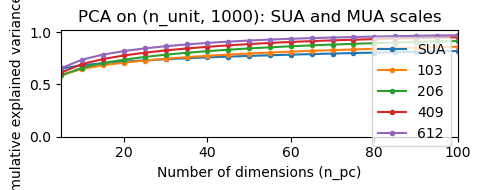

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

OUT_DIR = '/media/ubuntu/sda/TrippleN/customize/mua'
PSTH_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
UNIT_INFO_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'
SCALES_1000 = [103, 206, 409, 612]
N_REPEATS = 10
N_COMP_MAX = 100
DIM_STEP = 5
REPORT_DIMS = [5, 10, 25, 40, 50, 100, 150]

def get_responses_1000_sua():
    psth_data = np.load(PSTH_PATH, mmap_mode='r')
    unit_info = pd.read_pickle(UNIT_INFO_PATH)
    n_neurons = psth_data.shape[0]
    n_stimuli = psth_data.shape[1]
    n_time = psth_data.shape[2]
    best_r_time1 = unit_info['best_r_time1'].values
    best_r_time2 = unit_info['best_r_time2'].values
    neuron_responses = np.zeros((n_neurons, n_stimuli), dtype=np.float32)
    for neuron_idx in range(n_neurons):
        start_time = int(best_r_time1[neuron_idx])
        end_time = int(best_r_time2[neuron_idx])
        if start_time < 0:
            start_time = 0
        if end_time > n_time:
            end_time = n_time
        if end_time <= start_time:
            mid_time = n_time // 2
            start_time = max(0, mid_time - 5)
            end_time = min(n_time, mid_time + 5)
        psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
        neuron_responses[neuron_idx] = np.mean(psth_neuron, axis=1)
    return neuron_responses[:, :1000].astype(np.float64)

rng = np.random.default_rng(42)
data_dict = {'SUA': get_responses_1000_sua()}
for scale in SCALES_1000:
    fname = f'mua_responses_1000_{scale}.npy'
    path = os.path.join(OUT_DIR, fname)
    if not os.path.isfile(path):
        path = os.path.join(OUT_DIR, f'mua_responses_{scale}.npy')
    data_dict[str(scale)] = np.load(path).astype(np.float64)

min_n = min(X.shape[0] for X in data_dict.values())
n_comp = min(N_COMP_MAX, min_n, 1000)
dims_plot = np.arange(DIM_STEP, n_comp + 1, DIM_STEP)
print(f'min_n = {min_n}, n_comp = {n_comp}')



Cumulative explained variance ratio at dimensions 5/10/25/40/50/100/150 (mean±std over 100 subsamples):
                   5             10             25             40             50            100  150
scale                                                                                               
SUA    0.6465±0.0065  0.6796±0.0060  0.7275±0.0053  0.7561±0.0049  0.7706±0.0046  0.8188±0.0038  NaN
103    0.5922±0.0031  0.6492±0.0027  0.7302±0.0021  0.7754±0.0017  0.7974±0.0016  0.8624±0.0011  NaN
206    0.5864±0.0020  0.6605±0.0017  0.7642±0.0011  0.8198±0.0008  0.8459±0.0007  0.9175±0.0005  NaN
409    0.6161±0.0007  0.6972±0.0010  0.8054±0.0010  0.8620±0.0008  0.8881±0.0008  0.9529±0.0004  NaN
612    0.6577±0.0000  0.7395±0.0000  0.8466±0.0000  0.8991±0.0000  0.9223±0.0000  0.9729±0.0000  NaN


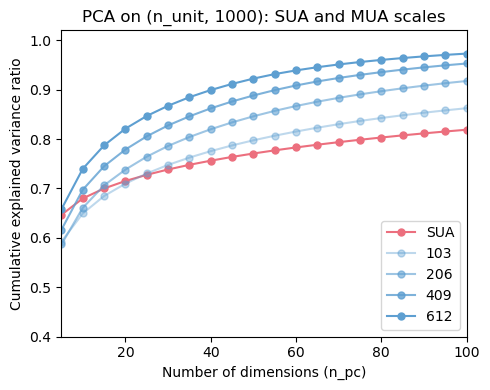

In [13]:
fig, ax = plt.subplots(figsize=(5, 4))
report_rows = []
all_scales = ['SUA'] + [str(s) for s in SCALES_1000]
scale_colors = {'SUA': '#EC6F7E', '103': ('#5E9FD1', 0.4), '206': ('#5E9FD1', 0.6), '409': ('#5E9FD1', 0.8), '612': ('#5E9FD1', 1.0)}

for scale in all_scales:
    X = data_dict[scale]
    n_unit = X.shape[0]
    cumvar_list = []
    for _ in range(N_REPEATS):
        idx = rng.choice(n_unit, size=min_n, replace=False)
        X_sub = X[idx, :]
        pca = PCA(n_components=n_comp)
        pca.fit(X_sub)
        cumvar = np.cumsum(pca.explained_variance_ratio_)
        cumvar_list.append(cumvar)
    cumvar_arr = np.array(cumvar_list)
    cumvar_mean = cumvar_arr.mean(axis=0)
    cumvar_std = cumvar_arr.std(axis=0)
    c = scale_colors[scale]
    plot_kw = {'color': c[0], 'alpha': c[1]} if isinstance(c, tuple) else {'color': c}
    ax.plot(dims_plot, cumvar_mean[dims_plot - 1], 'o-', markersize=5, label=scale, **plot_kw)
    row = {'scale': scale}
    for d in REPORT_DIMS:
        if d <= n_comp:
            row[d] = f"{cumvar_mean[d-1]:.4f}±{cumvar_std[d-1]:.4f}"
        else:
            row[d] = np.nan
    report_rows.append(row)

df_cumvar = pd.DataFrame(report_rows).set_index('scale')
print('Cumulative explained variance ratio at dimensions 5/10/25/40/50/100/150 (mean±std over 100 subsamples):')
print(df_cumvar.to_string())

ax.set_xlabel('Number of dimensions (n_pc)')
ax.set_ylabel('Cumulative explained variance ratio')
ax.set_title('PCA on (n_unit, 1000): SUA and MUA scales')
ax.set_xlim(DIM_STEP, N_COMP_MAX)
ax.set_ylim(0.4, 1.02)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'mua_1000_pca_elbow_all_scales.pdf'), bbox_inches='tight')
plt.show()

In [2]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, StratifiedKFold
from joblib import Parallel, delayed

cluster_info = loadmat('/media/ubuntu/sda/TrippleN/ClusInfo.mat')['Cluster_idx']
cluster_flat = np.asarray(cluster_info).flatten()
y_1000 = cluster_flat[:1000]
_, y_1000 = np.unique(y_1000, return_inverse=True)

OUT_DIR = '/media/ubuntu/sda/TrippleN/customize/mua'
PSTH_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_psth.npy'
UNIT_INFO_PATH = '/media/ubuntu/sda/TrippleN/customize/aggregate_response/all_subjects_unit_info.pkl'
SCALES_1000 = [103, 206, 409, 612]
N_REPEATS = 10
PC_DIMS = [5, 15, 25, 50]
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_responses_1000_sua():
    psth_data = np.load(PSTH_PATH, mmap_mode='r')
    unit_info = pd.read_pickle(UNIT_INFO_PATH)
    n_neurons, n_stimuli, n_time = psth_data.shape[0], psth_data.shape[1], psth_data.shape[2]
    best_r_time1 = unit_info['best_r_time1'].values
    best_r_time2 = unit_info['best_r_time2'].values
    neuron_responses = np.zeros((n_neurons, n_stimuli), dtype=np.float32)
    for neuron_idx in range(n_neurons):
        start_time = int(best_r_time1[neuron_idx])
        end_time = int(best_r_time2[neuron_idx])
        if start_time < 0:
            start_time = 0
        if end_time > n_time:
            end_time = n_time
        if end_time <= start_time:
            mid_time = n_time // 2
            start_time = max(0, mid_time - 5)
            end_time = min(n_time, mid_time + 5)
        psth_neuron = psth_data[neuron_idx, :n_stimuli, start_time:end_time]
        neuron_responses[neuron_idx] = np.mean(psth_neuron, axis=1)
    return neuron_responses[:, :1000].astype(np.float64)

rng = np.random.default_rng(42)
data_dict = {'SUA': get_responses_1000_sua()}
for scale in SCALES_1000:
    path = os.path.join(OUT_DIR, f'mua_responses_1000_{scale}.npy')
    if not os.path.isfile(path):
        path = os.path.join(OUT_DIR, f'mua_responses_{scale}.npy')
    data_dict[str(scale)] = np.load(path).astype(np.float64)

min_n = min(X.shape[0] for X in data_dict.values())
n_scale = len(data_dict)
accuracies = np.zeros((n_scale, len(PC_DIMS), N_REPEATS))
all_scales = ['SUA'] + [str(s) for s in SCALES_1000]
print(f'min_n={min_n}, 12-class decoding with {PC_DIMS} PCs, {N_REPEATS} repeats')

indices = {}
for scale_idx, scale in enumerate(all_scales):
    n_unit = data_dict[scale].shape[0]
    indices[scale_idx] = [np.random.default_rng(42 + scale_idx * 1000 + rep).choice(n_unit, size=min_n, replace=False) for rep in range(N_REPEATS)]

def run_one(scale_idx, rep):
    X = data_dict[all_scales[scale_idx]]
    idx = indices[scale_idx][rep]
    X_sub = X[idx, :].T
    pca = PCA(n_components=max(PC_DIMS))
    X_pca = pca.fit_transform(X_sub)
    accs = []
    for n_pc in PC_DIMS:
        acc = cross_val_score(SVC(kernel='linear', C=1.0), X_pca[:, :n_pc], y_1000, cv=CV, n_jobs=1).mean()
        accs.append(acc)
    return scale_idx, rep, accs

results = Parallel(n_jobs=-1, backend='loky')(delayed(run_one)(si, rep) for si in range(n_scale) for rep in range(N_REPEATS))
for scale_idx, rep, accs in results:
    for pc_idx, acc in enumerate(accs):
        accuracies[scale_idx, pc_idx, rep] = acc

print(f'accuracies shape: {accuracies.shape}')
print('Mean accuracy (scale x n_pc):')
df_acc = pd.DataFrame(accuracies.mean(axis=2), index=all_scales, columns=[f'{d}PC' for d in PC_DIMS])
print(df_acc.to_string())

min_n=5898, 12-class decoding with [5, 15, 25, 50] PCs, 10 repeats
accuracies shape: (5, 4, 10)
Mean accuracy (scale x n_pc):
        5PC    15PC    25PC    50PC
SUA  0.4284  0.5300  0.5331  0.5354
103  0.3610  0.5170  0.5023  0.5058
206  0.3488  0.4958  0.4829  0.4773
409  0.3637  0.4644  0.4830  0.4612
612  0.3540  0.4576  0.4782  0.4611


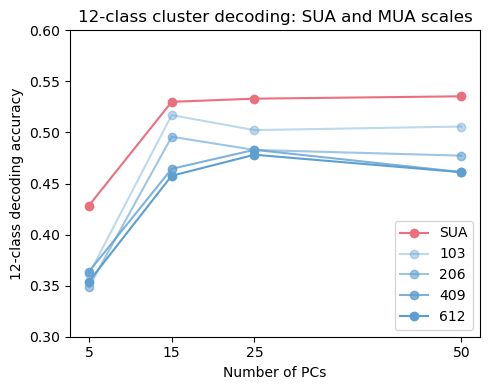

In [15]:
import matplotlib.pyplot as plt

scale_colors = {'SUA': '#EC6F7E', '103': ('#5E9FD1', 0.4), '206': ('#5E9FD1', 0.6), '409': ('#5E9FD1', 0.8), '612': ('#5E9FD1', 1.0)}
acc_mean = accuracies.mean(axis=2)
fig, ax = plt.subplots(figsize=(5, 4))
for scale_idx, scale in enumerate(all_scales):
    c = scale_colors[scale]
    plot_kw = {'color': c[0], 'alpha': c[1]} if isinstance(c, tuple) else {'color': c}
    ax.plot(PC_DIMS, acc_mean[scale_idx], 'o-', markersize=6, label=scale, **plot_kw)
ax.set_xlabel('Number of PCs')
ax.set_ylabel('12-class decoding accuracy')
ax.set_title('12-class cluster decoding: SUA and MUA scales')
ax.set_xticks(PC_DIMS)
ax.set_ylim(0.3, 0.6)
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'mua_1000_12class_decoding_by_pc.pdf'), bbox_inches='tight')
plt.show()